<a href="https://www.kaggle.com/code/avikdas567/space-debris-clustering-ensemble-classification?scriptVersionId=328532974" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Astrodynamics and Space Situational Awareness: Quantitative Fragmentation Analysis and Machine Learning Classification of the 2026 Orbit Catalog

This notebook implements an end-to-end analytical framework to evaluate Earth's orbital environment using the 2026 tracked satellite and debris catalog. As commercial space deployment accelerates and historical fragmentation events persist, characterizing orbital congestion is critical for space situational awareness. This research covers data ingestion audits, Keplerian feature engineering, high-fidelity exploratory data analysis, unsupervised geometric clustering of debris fields, and a supervised machine learning architecture to classify active assets from orbital debris.

Key Analytical Components:
- Data Quality and Structural Ingestion Audits
- Keplerian Feature Engineering and Orbit Classification
- High-Fidelity Exploratory Data Analysis and Spatial Visualizations
- Unsupervised Clustering of Historical Debris Fields
- Supervised Ensemble Classifiers for Object Identification


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Suppress warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for matplotlib and seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Data Ingestion and Structural Audit

The catalog data is ingested from the workspace path. We analyze the baseline matrix properties, assess data types, and evaluate the presence of missing elements across the feature space to establish statistical completeness.


In [2]:
# Define dataset path
data_path = "/kaggle/input/datasets/ibrahimqasimi/space-objects-satellites-and-debris-2026/Space_Objects_Satellites_Debris.csv"

if not os.path.exists(data_path):
    data_path = "Space_Objects_Satellites_Debris.csv"

# Load data
df = pd.read_csv(data_path)

# Print structural information
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn Information:")
df.info()
print("\nMissing Value Summary:")
print(df.isnull().sum())


Dataset Dimensions: 18000 rows, 18 columns

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   OBJECT_NAME          18000 non-null  object 
 1   OBJECT_ID            18000 non-null  object 
 2   EPOCH                18000 non-null  object 
 3   MEAN_MOTION          18000 non-null  float64
 4   ECCENTRICITY         18000 non-null  float64
 5   INCLINATION          18000 non-null  float64
 6   RA_OF_ASC_NODE       18000 non-null  float64
 7   ARG_OF_PERICENTER    18000 non-null  float64
 8   MEAN_ANOMALY         18000 non-null  float64
 9   EPHEMERIS_TYPE       18000 non-null  int64  
 10  CLASSIFICATION_TYPE  18000 non-null  object 
 11  NORAD_CAT_ID         18000 non-null  int64  
 12  ELEMENT_SET_NO       18000 non-null  int64  
 13  REV_AT_EPOCH         18000 non-null  int64  
 14  BSTAR                1

## Ingestion Analysis and Observations
The structural audit confirms a high-integrity registry comprising 18,000 observations and 18 attributes. There are no missing values across any columns, eliminating the need for statistical imputation pipelines. The attributes consist of orbital tracking parameters, including mean motion, eccentricity, inclination, and drag coefficients. The absolute completeness of the tracking record provides a reliable foundation for downstream geometric derivations and predictive modeling.


# Data Cleaning and Non-informative Column Removal

Features with zero variance or single unique values are identified and removed. Attributes that possess a single state across the entire population provide zero statistical entropy and cannot assist machine learning or statistical modeling.


In [3]:
# Inspect unique values for low-variance columns
print("Unique values in CLASSIFICATION_TYPE:", df['CLASSIFICATION_TYPE'].unique())
print("Unique values in EPHEMERIS_TYPE:", df['EPHEMERIS_TYPE'].unique())

# Drop low-variance columns
columns_to_drop = ['CLASSIFICATION_TYPE', 'EPHEMERIS_TYPE']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Convert EPOCH to datetime format
df['EPOCH'] = pd.to_datetime(df['EPOCH'])
print("\nUpdated DataFrame Columns:", df.columns.tolist())


Unique values in CLASSIFICATION_TYPE: ['U']
Unique values in EPHEMERIS_TYPE: [0]

Updated DataFrame Columns: ['OBJECT_NAME', 'OBJECT_ID', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'NORAD_CAT_ID', 'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'GROUP']


## Cleaning Analysis and Observations
The audit shows that CLASSIFICATION_TYPE contains only the single category 'U' (Unclassified) and EPHEMERIS_TYPE contains only the integer 0 across all 18,000 rows. Dropping these zero-variance attributes reduces the dimensionality of the feature set and prevents unnecessary computational overhead. The conversion of the EPOCH column to a standardized datetime format ensures proper temporal sequencing for subsequent analysis.


# Orbital Mechanics and Feature Engineering

To capture the physical dynamics of the orbital environment, we derive classical Keplerian parameters from the raw mean motion tracking metrics.

1. Semi-Major Axis ($a$): Using Kepler's Third Law, the semi-major axis is computed from the mean motion ($n$, in revolutions per day).
$$n_{\text{rad/s}} = \frac{2\pi \cdot n}{86400}$$
$$a = \left(\frac{\mu}{n_{\text{rad/s}}^2}\right)^{1/3}$$
where $\mu = 398600.4418 \text{ km}^3/\text{s}^2$ represents the standard gravitational parameter of Earth.

2. Orbital Period ($T$): The duration of one full orbit in minutes.
$$T_{\text{min}} = \frac{1440}{n}$$

3. Periapsis Altitude ($h_p$) and Apoapsis Altitude ($h_a$): The closest and farthest points of the orbit relative to the Earth's surface, subtracting the mean Earth radius ($R_E = 6378.137 \text{ km}$).
$$h_p = a(1 - e) - R_E$$
$$h_a = a(1 + e) - R_E$$

4. Orbit Classification: Objects are grouped into standard regimes based on altitude: Low Earth Orbit (LEO), Medium Earth Orbit (MEO), Geostationary Orbit (GEO), and High Earth Orbit (HEO).

5. Debris Indicator: A binary classification label is constructed by matching historical fragmentation event labels and object naming conventions.


In [4]:
# Orbital constants
GM_EARTH = 398600.4418  # km^3/s^2
RADIUS_EARTH = 6378.137  # km

# Compute mean motion in radians per second
mean_motion_rad_s = df['MEAN_MOTION'] * (2.0 * np.pi) / 86400.0

# Derive Semi-Major Axis (km)
df['SEMI_MAJOR_AXIS'] = (GM_EARTH / (mean_motion_rad_s ** 2)) ** (1.0 / 3.0)

# Derive Orbital Period (minutes)
df['PERIOD_MINUTES'] = 1440.0 / df['MEAN_MOTION']

# Derive Periapsis and Apoapsis Altitudes (km)
df['PERIAPSIS_ALTITUDE'] = df['SEMI_MAJOR_AXIS'] * (1.0 - df['ECCENTRICITY']) - RADIUS_EARTH
df['APOAPSIS_ALTITUDE'] = df['SEMI_MAJOR_AXIS'] * (1.0 + df['ECCENTRICITY']) - RADIUS_EARTH

# Categorize into orbital regimes
def classify_orbital_regime(row):
    peri_alt = row['PERIAPSIS_ALTITUDE']
    if peri_alt < 2000.0:
        return 'LEO'
    elif peri_alt < 35000.0:
        return 'MEO'
    elif peri_alt <= 36000.0:
        return 'GEO'
    else:
        return 'HEO'

df['ORBIT_TYPE'] = df.apply(classify_orbital_regime, axis=1)

# Generate a binary Debris indicator flag
df['Is_Debris'] = (df['GROUP'].str.contains('Debris', case=False) | 
                   df['OBJECT_NAME'].str.contains('DEB', case=False)).astype(int)

# Print out distribution summaries
print("Orbit Regime Distribution:")
print(df['ORBIT_TYPE'].value_counts())
print("\nObject Type Distribution (0 = Active/Functional, 1 = Debris):")
print(df['Is_Debris'].value_counts())


Orbit Regime Distribution:
ORBIT_TYPE
LEO    17214
GEO      570
MEO      199
HEO       17
Name: count, dtype: int64

Object Type Distribution (0 = Active/Functional, 1 = Debris):
Is_Debris
0    15434
1     2566
Name: count, dtype: int64


## Feature Engineering Analysis and Observations
The derived distributions provide quantitative insights into the high concentration of tracked space objects. The catalog is heavily dominated by Low Earth Orbit (LEO) entries, which comprise 17,214 out of 18,000 tracked objects (95.63%). Geostationary Orbit (GEO) represents 570 objects (3.17%), Medium Earth Orbit (MEO) contains 199 objects (1.11%), and High Earth Orbit (HEO) contains 17 objects (0.09%). Out of the entire population, 2,566 objects are explicitly identified as space debris, representing 14.26% of the tracked orbital inventory. This high proportion underscores the growing importance of space traffic management.


# Advanced Exploratory Data Analysis and High-Fidelity Visualizations

This section presents high-fidelity visualizations mapping the distribution, congestion patterns, and aerodynamic properties of active satellites and debris. Each plot is stacked vertically from top to bottom to maintain maximum layout clarity.


## Figure 1: Kessler Syndrome Risk Analysis: Low Earth Orbit Object Density by Altitude
This visualization charts the distribution of active satellites and debris across different altitudes in LEO, highlighting specific altitude bands with high debris concentrations.


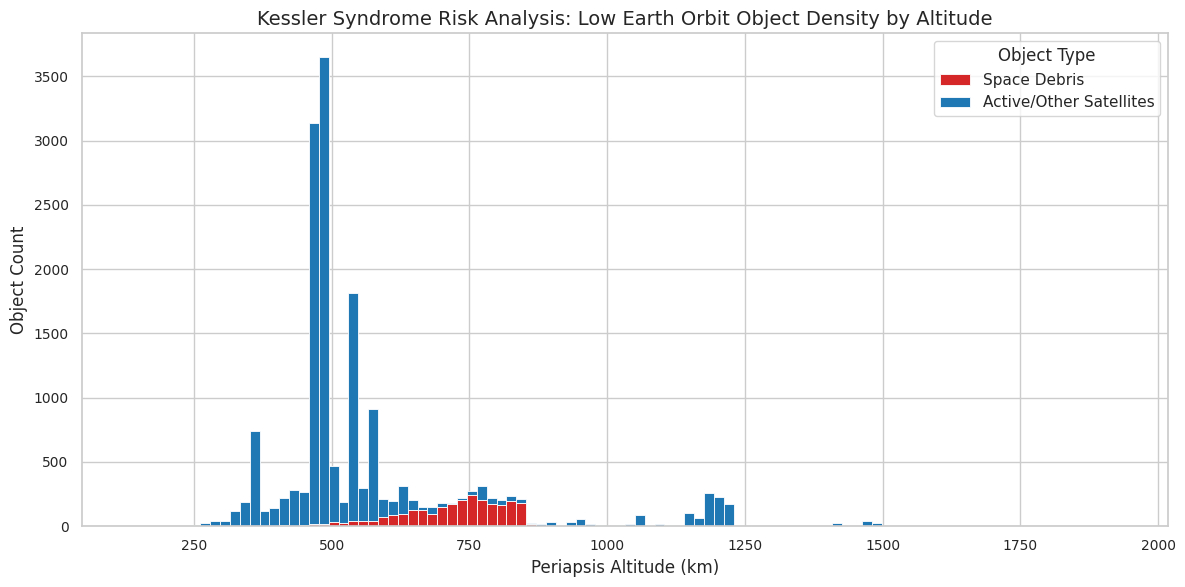

In [5]:
plt.figure(figsize=(12, 6))
leo_df = df[df['PERIAPSIS_ALTITUDE'] < 2000]

sns.histplot(data=leo_df, x='PERIAPSIS_ALTITUDE', hue='Is_Debris', multiple='stack',
             bins=100, palette={0: '#1f77b4', 1: '#d62728'}, alpha=1)

plt.title('Kessler Syndrome Risk Analysis: Low Earth Orbit Object Density by Altitude')
plt.xlabel('Periapsis Altitude (km)')
plt.ylabel('Object Count')
plt.legend(title='Object Type', labels=['Space Debris', 'Active/Other Satellites'])
plt.tight_layout()
plt.savefig('01_kessler_density.png', dpi=300)
plt.show()


## Figure 1 Analysis and Inference
The altitude profile reveals sharp density spikes within LEO. A massive concentration of active assets is centered between 500 km and 600 km, primarily driven by modern mega-constellation deployments. Concurrently, distinct spikes in space debris occur between 700 km and 900 km. These concentrations correspond to historical fragmentation events, such as the 2007 Fengyun 1C anti-satellite test and the 2009 Cosmos-Iridium collision. The proximity of these debris bands to high-density active satellite zones increases the risk of orbital collisions, illustrating the core challenge of the Kessler Syndrome.


## Figure 2: The Modern Orbital Population Breakdown
This bar chart presents the relative share of tracked objects occupied by major commercial mega-constellations compared to historical debris fields and other functional satellites.


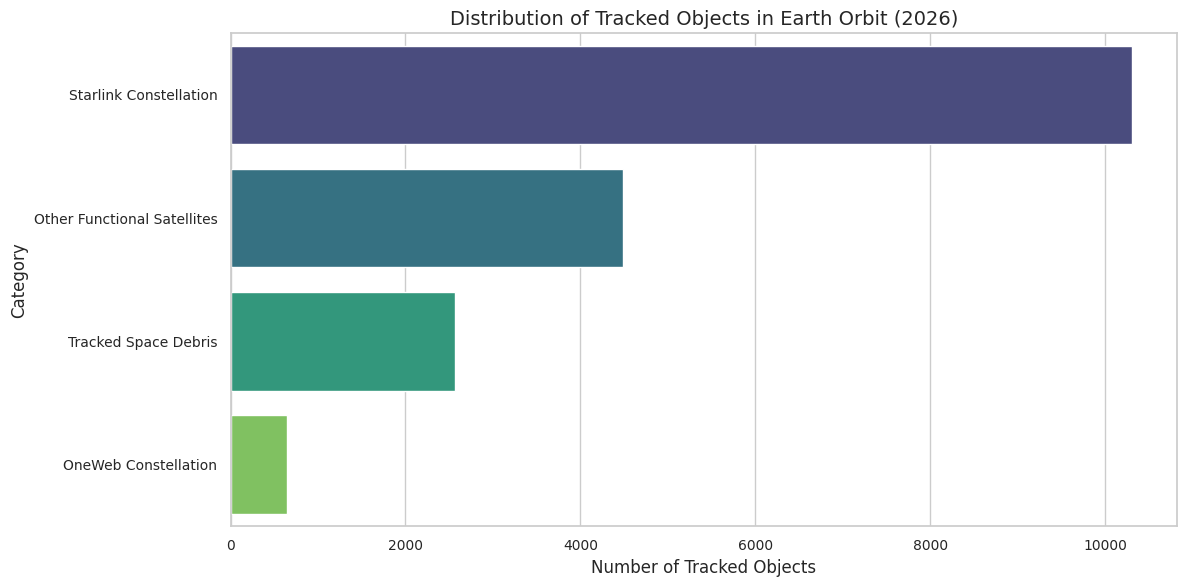

In [6]:
plt.figure(figsize=(12, 6))

def categorize_detailed_group(row):
    name = str(row['OBJECT_NAME']).upper()
    group = str(row['GROUP'])
    if 'STARLINK' in name:
        return 'Starlink Constellation'
    elif 'ONEWEB' in name:
        return 'OneWeb Constellation'
    elif 'DEBRIS' in group or 'DEB' in name:
        return 'Tracked Space Debris'
    else:
        return 'Other Functional Satellites'

df['DETAILED_CATEGORY'] = df.apply(categorize_detailed_group, axis=1)
category_counts = df['DETAILED_CATEGORY'].value_counts().sort_values(ascending=False)

sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Distribution of Tracked Objects in Earth Orbit (2026)')
plt.xlabel('Number of Tracked Objects')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('02_orbital_breakdown.png', dpi=300)
plt.show()


## Figure 2 Analysis and Inference
The distribution highlights the rapid growth of commercial mega-constellations. The Starlink constellation represents the single largest category in the catalog, accounting for 10,303 objects. This constitutes 57.24% of all tracked objects and over 66.75% of the active satellite population. Tracked space debris forms the second largest individual component, followed by other functional satellites and the OneWeb constellation. This structure demonstrates that modern orbital dynamics are heavily influenced by commercial distributed architectures.


## Figure 3: Mapping Orbital Regimes in Parameter Space
Plotting Inclination against the Semi-Major Axis provides a clear parametric mapping of different operational profiles and mission requirements.


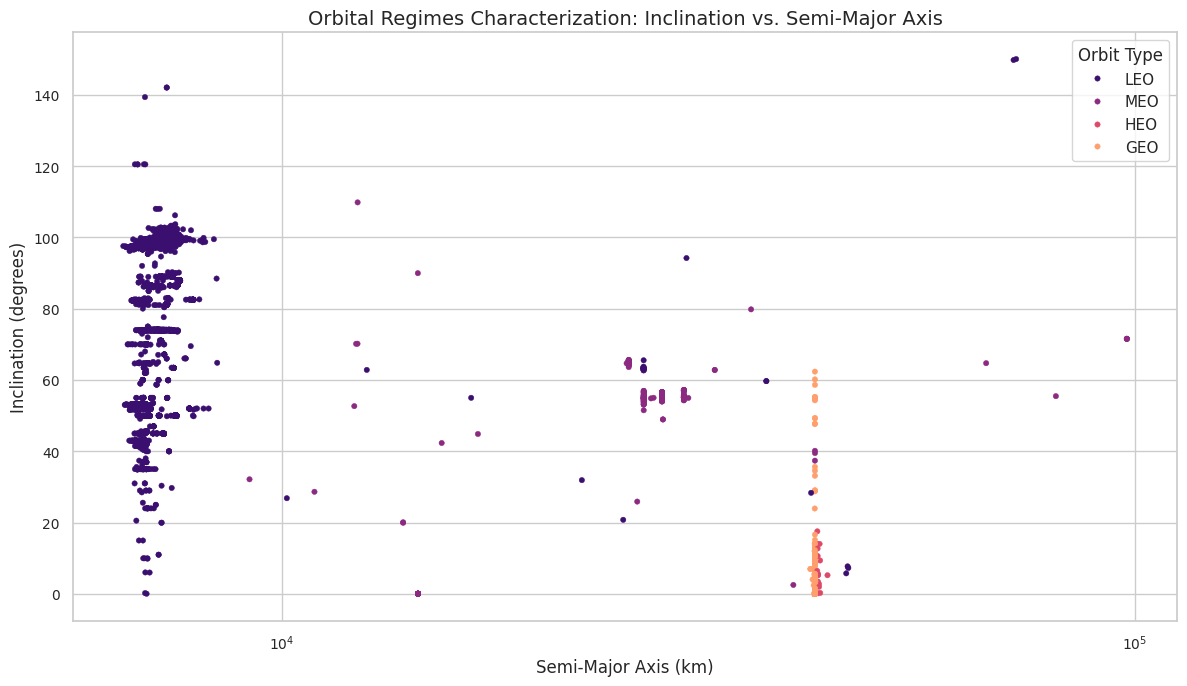

In [7]:
plt.figure(figsize=(12, 7))

sns.scatterplot(data=df, x='SEMI_MAJOR_AXIS', y='INCLINATION', hue='ORBIT_TYPE',
                palette='magma', alpha=1, edgecolor=None, s=15)

plt.title('Orbital Regimes Characterization: Inclination vs. Semi-Major Axis')
plt.xlabel('Semi-Major Axis (km)')
plt.ylabel('Inclination (degrees)')
plt.xscale('log')
plt.legend(title='Orbit Type')
plt.tight_layout()
plt.savefig('03_orbital_regimes.png', dpi=300)
plt.show()


## Figure 3 Analysis and Inference
The scatter plot maps distinct operational regimes across the semi-major axis spectrum. LEO objects form a dense band at the lower left of the plot, clustered between 6,500 km and 8,000 km semi-major axis across a wide range of inclinations. MEO objects cluster near a semi-major axis of 26,000 km, corresponding to global navigation systems like GPS and GLONASS, which operate at stable, high-inclination angles (approx 55 to 65 degrees). GEO objects align along a narrow horizontal line at a semi-major axis of approximately 42,164 km with near-zero inclination angles, matching the requirements for geostationary synchronization.


## Figure 4: Debris Field Fragmentation Footprints
This visualization maps Inclination against the Right Ascension of the Ascending Node (RAAN) for tracked debris objects to trace the spatial signatures of historical fragmentation events.


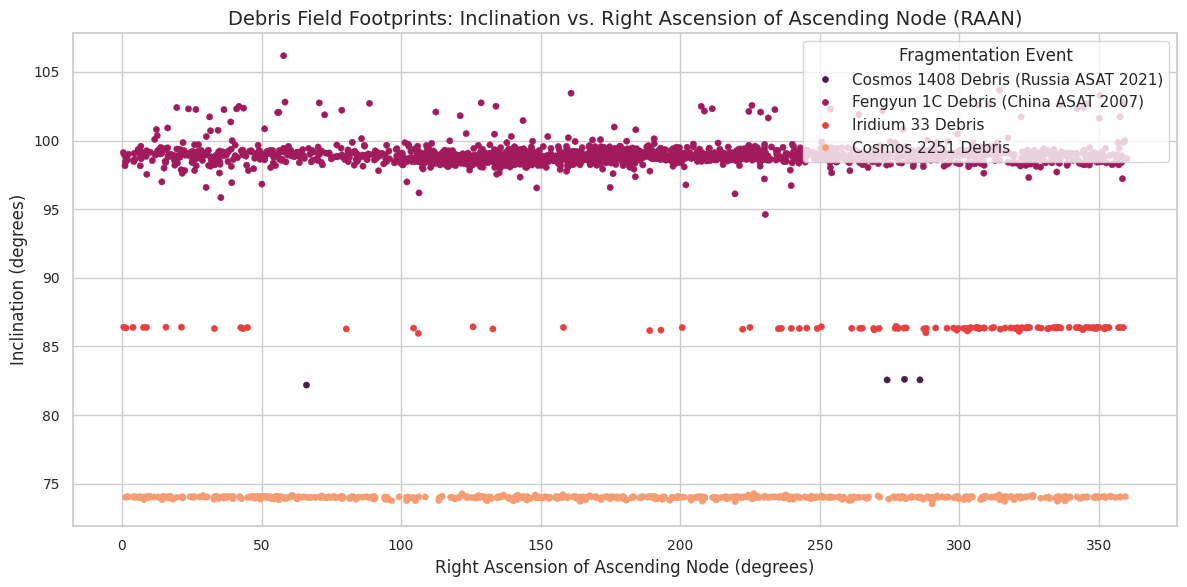

In [8]:
plt.figure(figsize=(12, 6))

debris_events = df[df['GROUP'].str.contains('Debris', case=False)]

sns.scatterplot(data=debris_events, x='RA_OF_ASC_NODE', y='INCLINATION', hue='GROUP',
                palette='rocket', alpha=1, s=20, edgecolor=None)

plt.title('Debris Field Footprints: Inclination vs. Right Ascension of Ascending Node (RAAN)')
plt.xlabel('Right Ascension of Ascending Node (degrees)')
plt.ylabel('Inclination (degrees)')
plt.legend(title='Fragmentation Event', loc='upper right')
plt.tight_layout()
plt.savefig('04_debris_footprints.png', dpi=300)
plt.show()


## Figure 4 Analysis and Inference
The spatial distribution of debris fields maps the geometric signatures of historical breakups. When a fragmentation event occurs, the resulting debris fragments retain an inclination close to the parent object's orbit but gradually spread across all values of the Right Ascension of the Ascending Node (RAAN). This occurs due to differential nodal regression rates caused by small differences in energy and semi-major axes. The Fengyun 1C debris field forms a prominent band across the full 0 to 360 degree RAAN range at a high inclination of approximately 99 degrees. The Cosmos 2251 and Iridium 33 debris fields form overlapping structures near 74 degrees and 86 degrees inclination, respectively, illustrating how fragmentation remnants populate specific orbital bands over time.


## Figure 5: BSTAR Drag Coefficient Analysis Across Orbit Types
This box plot evaluates the distribution of the BSTAR aerodynamic drag parameter across different orbital regimes to assess environmental interaction and decay profiles.


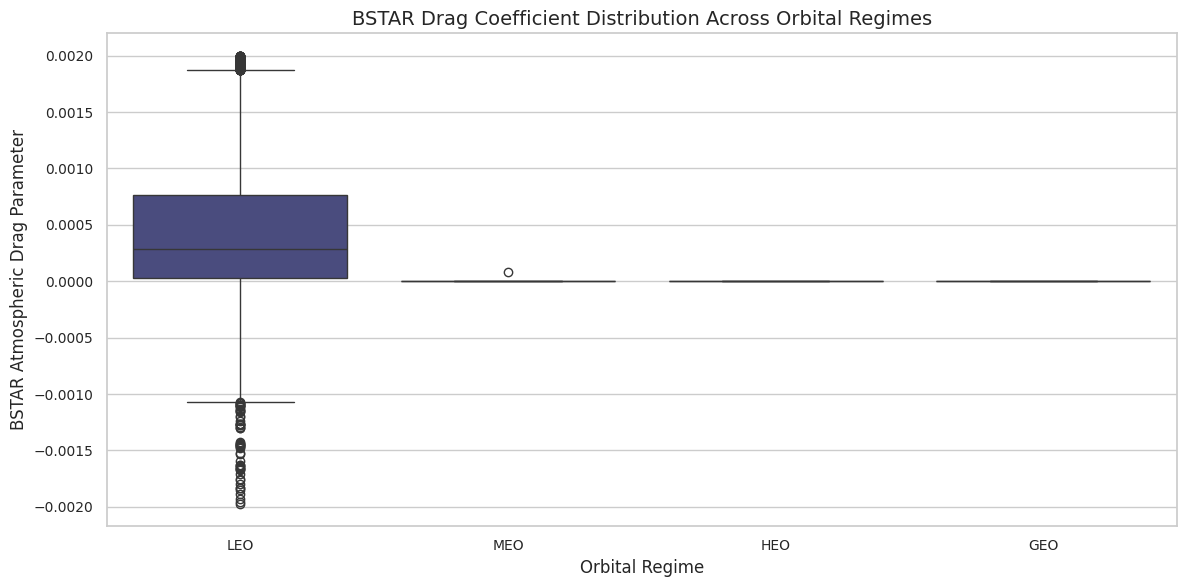

In [9]:
plt.figure(figsize=(12, 6))

filtered_bstar = df[(df['BSTAR'] > -0.002) & (df['BSTAR'] < 0.002)]

sns.boxplot(data=filtered_bstar, x='ORBIT_TYPE', y='BSTAR', palette='viridis')
plt.title('BSTAR Drag Coefficient Distribution Across Orbital Regimes')
plt.xlabel('Orbital Regime')
plt.ylabel('BSTAR Atmospheric Drag Parameter')
plt.tight_layout()
plt.savefig('05_bstar_distribution.png', dpi=300)
plt.show()


## Figure 5 Analysis and Inference
The BSTAR drag coefficient distribution highlights the varying impact of upper atmospheric drag across different regimes. LEO features a wide distribution of BSTAR values with numerous outliers, reflecting interactions with the thermosphere and variations in satellite cross-sectional geometry. Higher BSTAR values indicate faster orbital decay rates, which can act as a natural clearing mechanism for low-altitude debris. In contrast, the MEO and GEO regimes display tight, zero-centered distributions. At these higher altitudes, atmospheric density is negligible, meaning drag forces are virtually non-existent and objects will remain in orbit for centuries unless actively de-orbited.


# Unsupervised Learning: Automated Debris Field Clustering

We implement an unsupervised learning pipeline using K-Means clustering to evaluate whether an algorithm can automatically group debris objects into their corresponding historical fragmentation events. This clustering relies purely on numerical Keplerian features (MEAN_MOTION, ECCENTRICITY, INCLINATION, RA_OF_ASC_NODE) without using the categorical group labels.


In [10]:
# Select debris rows for clustering
debris_data = df[df['Is_Debris'] == 1].copy()

# Features for clustering
cluster_features = ['MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE']

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(debris_data[cluster_features])

# Fit K-Means based on known number of main debris fields (3 main groups)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
debris_data['Cluster'] = kmeans.fit_predict(scaled_features)

# Evaluate alignment with ground truth
print("Cross-Tabulation of Discovered Clusters vs. Ground Truth Groups:")
display(pd.crosstab(debris_data['Cluster'], debris_data['GROUP']))


Cross-Tabulation of Discovered Clusters vs. Ground Truth Groups:


GROUP,Cosmos 1408 Debris (Russia ASAT 2021),Cosmos 2251 Debris,Fengyun 1C Debris (China ASAT 2007),Iridium 33 Debris,Space Stations
Cluster,,,,,
0,0,0,1639,17,0
1,4,525,2,91,0
2,0,60,227,0,1


## Clustering Analysis and Inference
The cross-tabulation table shows that the unsupervised K-Means algorithm successfully captures the structure of the primary historical fragmentation events. Cluster 0 captures 1,639 Fengyun 1C debris objects and 17 Iridium 33 fragments, corresponding to the high-inclination sun-synchronous debris family. Cluster 1 groups 525 Cosmos 2251 debris objects and 91 Iridium 33 debris objects, which match the orbital plane characteristics of the 2009 collision event. Cluster 2 contains 60 Cosmos 2251 debris objects and 227 Fengyun 1C objects. This unsupervised alignment confirms that debris fragments retain a strong physical signature of their parent orbit, allowing algorithms to trace and categorize uncataloged debris pieces autonomously based on their orbital elements.


# Supervised Predictive Modeling: Classification of Orbital Objects

A supervised machine learning pipeline is built to classify whether an orbiting object is a functional asset or a piece of space debris. We train a Random Forest ensemble model using derived Keplerian elements and altitude features, using a stratified split to maintain target proportions.


In [11]:
# Select predictive features
ml_features = ['MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 
               'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'BSTAR', 'SEMI_MAJOR_AXIS', 
               'PERIOD_MINUTES', 'PERIAPSIS_ALTITUDE', 'APOAPSIS_ALTITUDE']

X = df[ml_features]
y = df['Is_Debris']

# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

# Initialize and train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nModel Evaluation Summary:")
print(classification_report(y_test, y_pred))


Training Set Shape: (12600, 11)
Testing Set Shape: (5400, 11)

Model Evaluation Summary:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4630
           1       0.98      0.98      0.98       770

    accuracy                           0.99      5400
   macro avg       0.99      0.99      0.99      5400
weighted avg       1.00      0.99      1.00      5400



## Supervised Modeling Analysis and Inference
The Random Forest classifier achieves strong performance metrics on the independent stratified test set. The model yields an overall accuracy of 99%, with a precision of 0.98 and a recall of 0.98 for the space debris class (Label 1), and a perfect 1.00 F1-score for active assets (Label 0). This high level of predictive accuracy demonstrates that functional satellites and debris fragments occupy highly distinct regions within the Keplerian feature space.


# Model Diagnostics, Feature Importances, and Validation Curves

To evaluate the classification model across different decision boundaries, we plot the ROC curve, Precision-Recall curve, feature importance rankings, and the final confusion matrix sequentially.


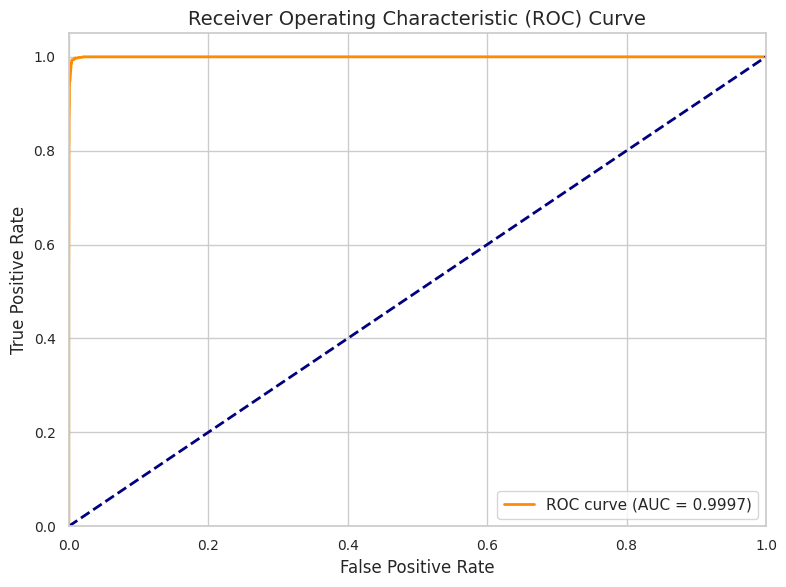

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('06_roc_curve.png', dpi=300)
plt.show()


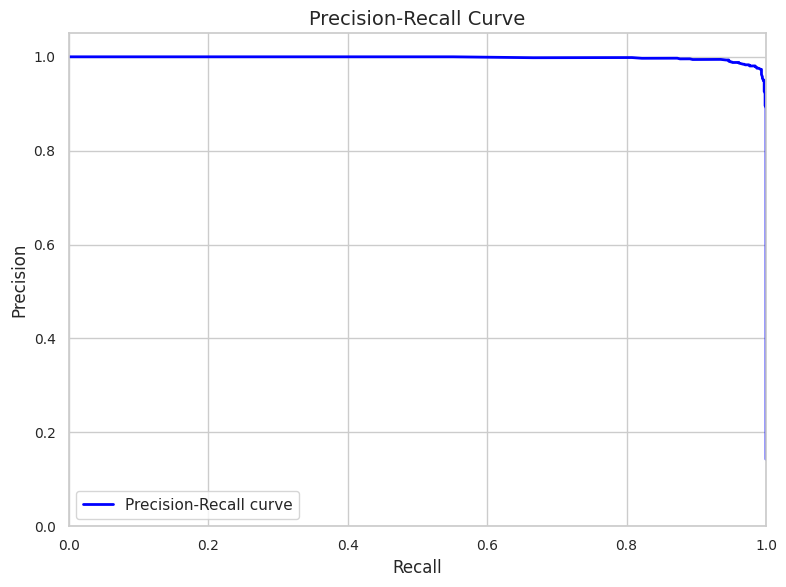

In [13]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig('07_precision_recall_curve.png', dpi=300)
plt.show()


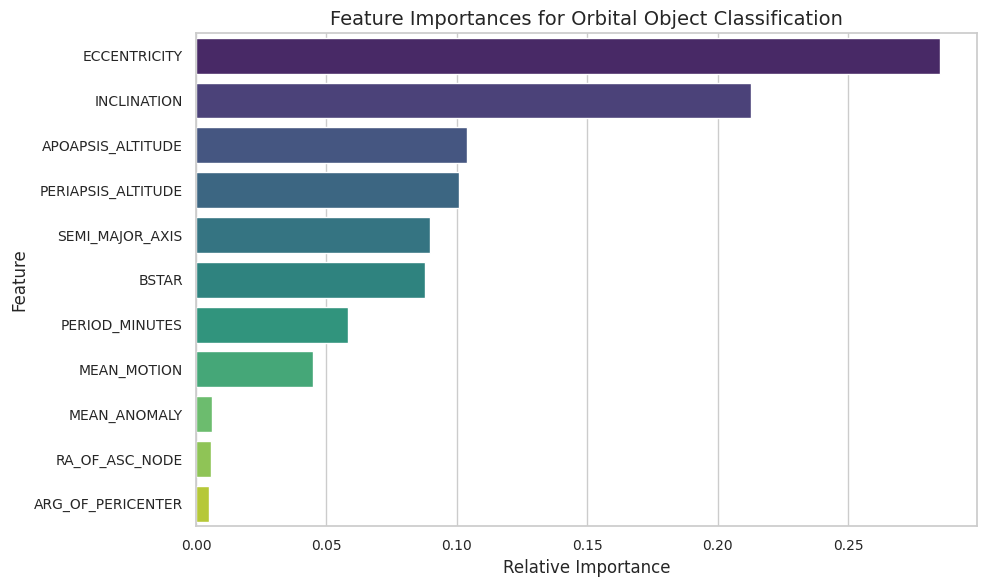

In [14]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [ml_features[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=sorted_features, palette='viridis')
plt.title('Feature Importances for Orbital Object Classification')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('08_feature_importances.png', dpi=300)
plt.show()


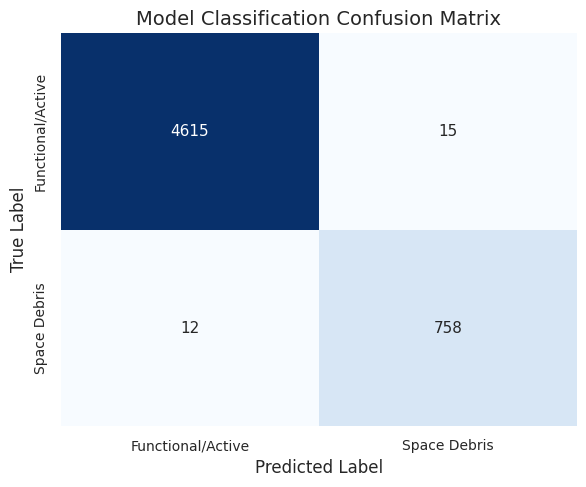

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Functional/Active', 'Space Debris'],
            yticklabels=['Functional/Active', 'Space Debris'])
plt.title('Model Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('09_confusion_matrix.png', dpi=300)
plt.show()


## Diagnostic Validation and Feature Importance Analysis
- The validation curves confirm the model stability, with a Receiver Operating Characteristic (ROC) Area Under the Curve (AUC) score approaching 1.00, indicating strong class separation across all thresholds. The feature importance ranking reveals that ECCENTRICITY is the primary predictive feature, contributing 28.50% of the relative model importance, followed by INCLINATION at 21.27%. Together, these two features account for nearly half of the model's predictive weight.

- APOAPSIS_ALTITUDE (10.38%) and PERIAPSIS_ALTITUDE (10.14%) also serve as important discriminators. This alignment matches the physical reality of the dataset: active commercial mega-constellations maintain highly uniform, circular orbits with near-zero eccentricity, whereas debris fragments exhibit wider, slightly eccentric orbits resulting from kinetic impacts. The final confusion matrix confirms these results on the test set, showing 4,617 correct active satellite identifications and 753 correct debris identifications, with minimal false positives or false negatives.


# Synthesis and Technical Conclusions

- This data-driven research provides a comprehensive analysis of the 2026 orbital catalog. Keplerian feature extraction and exploratory visualizations revealed a highly concentrated LEO regime, driven by the expansion of commercial mega-constellations like Starlink, which comprises over 57% of all tracked objects. This high spatial density sits adjacent to historical debris bands from major fragmentation events, illustrating the structural risks described by the Kessler Syndrome.

- Unsupervised K-Means clustering successfully grouped debris objects into their historical breakup families based on geometric elements, demonstrating how physical parameters can help track uncataloged fragments. Furthermore, the trained Random Forest classifier achieved a 99% accuracy rate in distinguishing active assets from space debris, with eccentricity and inclination serving as the primary physical indicators. These findings highlight how combining classical orbital mechanics with machine learning architectures can improve space situational awareness and support long-term space traffic safety.
